# 1. Canonical mini-ELF

The simplest pipeline: a 15-segment ring of circular sub-apertures, no atmosphere, no coronagraph. Loaded from the bundled `elf_15seg` preset.

The `elf_15seg` preset is a small YAML config bundled with the package. It declares the pupil grid, aperture, one PTT corrector, **two filters** (500 nm and 1 µm) sharing the same focal-plane sampling, and a single intensity output. Let's read it directly so the shape of a real config is visible.

In [1]:
from importlib.resources import files

config_text = files("telescope_sim.presets").joinpath("elf_15seg.yaml").read_text()
print(config_text)


# elf_15seg preset — mini-ELF with 15 circular sub-apertures on a 1.25 m ring,
# two filters (500 nm + 1000 nm), broadband sampling at 5 wavelengths per
# filter. Matches the layout used by the canonical-family fixtures.

pupil:
  resolution: 256
  extent: 3.1563881637  # (2*telescopeR + chord_mir_diameter) * 1.05

aperture:
  type: segmented_circular
  segment_diameter: 0.5197792270  # 2 * 1.25 * sin(pi/15)
  layout: elf
  n_segments: 15
  ring_radius: 1.25
  supersample: 16

correctors:
  segments:
    type: segmented_ptt
    piston_scale: 1.0e-6
    tip_tilt_scale: 1.0e-6
    wavefront_role: actuate
    target_strategy: actuators
    target: true

corrector_chain: [segments]

focal_planes:
  filter1:
    type: angular
    central_lam: 0.5e-6
    focal_extent: 1.0
    focal_res: 128
    fractional_bandwidth: 0.05
    num_samples: 5
  filter2:
    type: angular
    central_lam: 1.0e-6
    focal_extent: 1.0
    focal_res: 128
    fractional_bandwidth: 0.05
    num_samples: 5

outputs:


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from telescope_sim import TelescopeSim
from telescope_sim.helpers.diagnostics import plot_opd_and_psfs

sim = TelescopeSim.from_preset("elf_15seg")
print("correctors:", list(sim.correctors))
print("focal planes:", list(sim.focal_planes))


correctors: ['segments']
focal planes: ['filter1', 'filter2']


By convention in these tutorials, every PSF is shown next to the **cumulative pupil OPD** that produced it — the wavefront state at the back of the corrector chain (and including any external atmosphere). Setting `meas_pupil_opd=True` on `sample()` returns `out['pupil_opd']` as an `hcipy.Field`; the helper `plot_opd_and_psfs` in `telescope_sim.helpers.diagnostics` handles the layout (OPD via `hcipy.imshow_field(mask=sim.aperture.field)`, PSFs via `imshow(norm=LogNorm(...))`, colorbars everywhere).

Sample at rest (no actuators applied). The pupil OPD is ~0 inside the aperture. Both filters share that same wavefront, but their PSFs differ in scale — the 1 µm Airy disk is twice the angular size of the 500 nm one because λ/D scales linearly with λ.

psf shape: (128, 128, 2)
strehls: {'filter1': 1.0, 'filter2': 1.0}
pupil_opd RMS (nm): 0.0


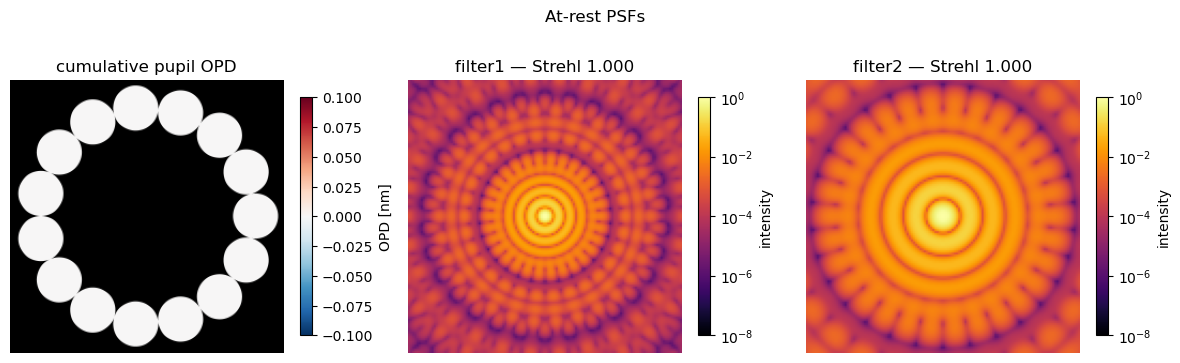

In [3]:
out = sim.sample(meas_strehl=True, meas_pupil_opd=True)
print('psf shape:', out['images']['psf'].shape)
print('strehls:', out['strehls'])
print('pupil_opd RMS (nm):', 1e9 * out['pupil_opd'].std())
plot_opd_and_psfs(sim, out, suptitle='At-rest PSFs')
plt.show()


Apply random per-segment piston/tip/tilt errors and resample. The OPD panel now shows the per-segment phase errors directly, and both filters' PSFs degrade — but each degrades differently because Strehl scales as `exp(-(2π σ_OPD / λ)²)`: the same OPD error costs more Strehl at shorter wavelengths.

strehls with errors: {'filter1': 0.050454922839294536, 'filter2': 0.11317076514003656}
pupil_opd RMS (nm): 126.07078293784832


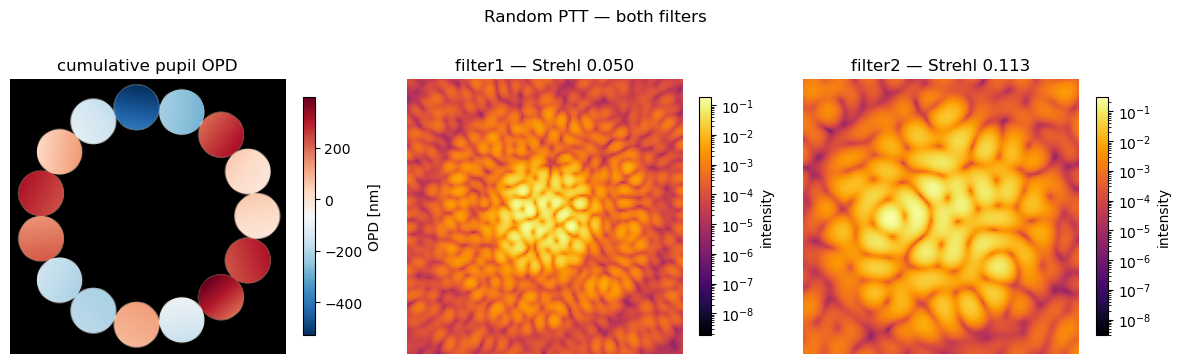

In [4]:
rng = np.random.default_rng(0)
ptt = rng.normal(scale=0.1, size=(15, 3))
out = sim.sample(
    actuations={"segments": ptt}, meas_strehl=True, meas_pupil_opd=True,
)
print('strehls with errors:', out['strehls'])
print('pupil_opd RMS (nm):', 1e9 * out['pupil_opd'].std())
plot_opd_and_psfs(sim, out, suptitle='Random PTT — both filters')
plt.show()


## Detector noise

The `noisy_detector` post-processor wraps HCIPy's `NoisyDetector` (read noise + dark current + flat-field + optional photon shot noise). It's a single-focal-plane processor — its underlying detector needs exactly one focal grid — so the simplest demo derives a single-filter config from the preset and stacks `noisy_detector` under the existing `intensity` tap.

Per-sample photon flux is plumbed through `sim.sample(output_overrides={"psf": {"int_phot_flux": ...}})`: the same noisy sim covers a wide flux range without rebuilding.

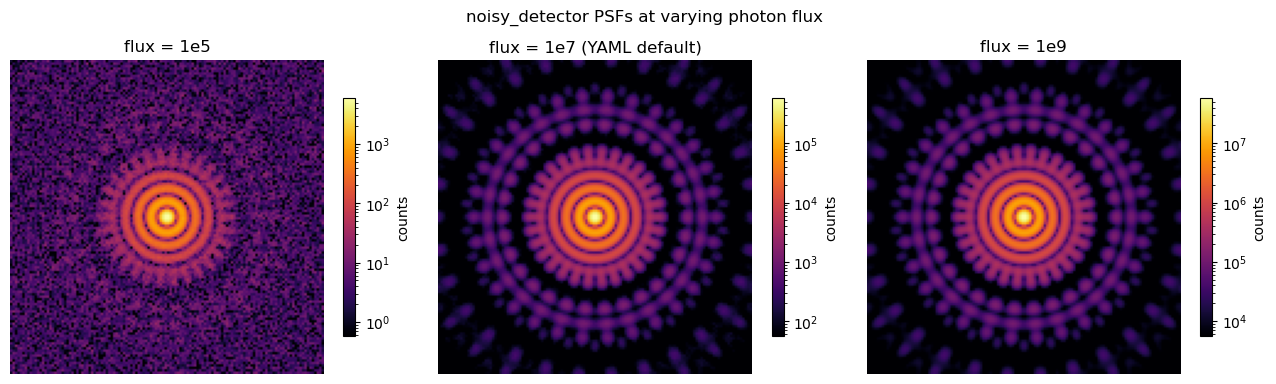

In [5]:
from telescope_sim.config.schema import SimConfig
from telescope_sim.config.loader import build

# Derived single-filter config so the single-focal-plane noisy_detector
# constraint is satisfied. Re-uses the 15-segment ELF aperture + PTT
# corrector from the preset.
noisy_cfg = {
    'pupil': {'resolution': 256, 'extent': 3.1563881637},
    'aperture': {
        'type': 'segmented_circular',
        'segment_diameter': 0.5197792270,
        'layout': 'elf', 'n_segments': 15, 'ring_radius': 1.25,
        'supersample': 16,
    },
    'correctors': {
        'segments': {
            'type': 'segmented_ptt',
            'piston_scale': 1.0e-6, 'tip_tilt_scale': 1.0e-6,
            'wavefront_role': 'actuate',
            'target_strategy': 'actuators', 'target': True,
        },
    },
    'corrector_chain': ['segments'],
    'focal_planes': {
        'filter1': {
            'type': 'angular', 'central_lam': 0.5e-6,
            'focal_extent': 1.0, 'focal_res': 128,
            'fractional_bandwidth': 0.05, 'num_samples': 5,
        },
    },
    'outputs': {
        'psf': {
            'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
            'post_processing': [
                {'type': 'noisy_detector',
                 'int_phot_flux': 1.0e7,
                 'detector': {
                     'read_noise': 5.0,
                     'dark_current_rate': 0.0,
                     'flat_field': 0.0,
                     'include_photon_noise': True,
                 }},
            ],
        },
    },
}
noisy_sim = build(SimConfig.model_validate(noisy_cfg))
np.random.seed(0)
out_clean = noisy_sim.sample()  # default flux = 1e7 photons/m^2
out_low = noisy_sim.sample(output_overrides={'psf': {'int_phot_flux': 1.0e5}})
out_high = noisy_sim.sample(output_overrides={'psf': {'int_phot_flux': 1.0e9}})

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, out_i, title in zip(
    axes,
    [out_low, out_clean, out_high],
    ['flux = 1e5', 'flux = 1e7 (YAML default)', 'flux = 1e9'],
):
    img = out_i['images']['psf'][..., 0]
    vmax = float(img.max())
    im = ax.imshow(
        img, norm=LogNorm(vmin=max(vmax * 1e-4, 1e-3), vmax=vmax),
        cmap='inferno',
    )
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label='counts')
fig.suptitle('noisy_detector PSFs at varying photon flux')
plt.tight_layout()
plt.show()


## Extended-source imaging via `convolve_image`

The `convolve_image` post-processor convolves a caller-supplied scene with the focal-plane PSF (normalized by the at-rest reference PSF sum, so the kernel integrates to ~1). Stacked **before** `noisy_detector`, the chain is `intensity → convolve_image → noisy_detector` — the physically correct order for noisy extended-source imaging.

Below the convolve scene is injected per-sample via `output_overrides`, so the same sim can imaging different scenes without rebuilding. To compare convolution alone vs. convolution + noise we build two sims (post-processing chains are fixed at sim-build time).

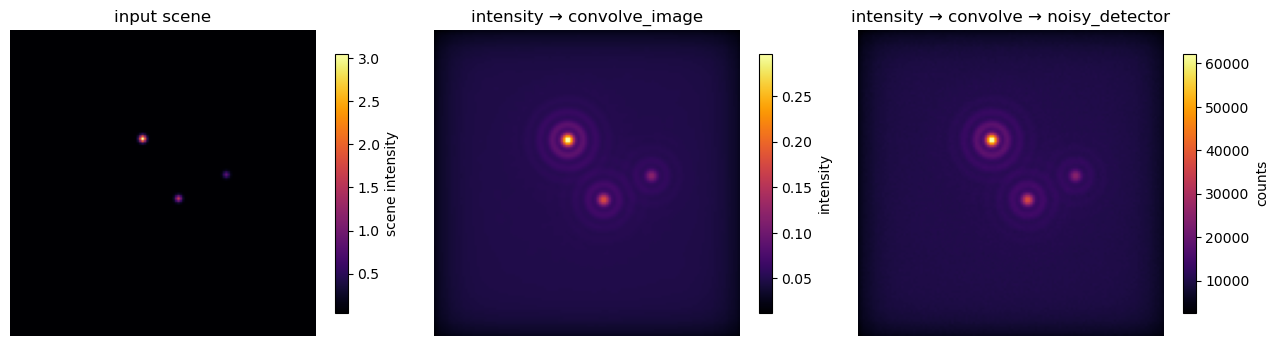

In [6]:
# Build a synthetic extended scene (three off-axis point sources +
# a smooth background) at the same resolution as the focal grid.
scene = np.zeros((128, 128), dtype=np.float64)
ys, xs = np.indices(scene.shape)
for cy, cx, amp, sig in [(45, 55, 3.0, 1.0),
                          (70, 70, 1.5, 1.0),
                          (60, 90, 0.8, 1.0)]:
    scene += amp * np.exp(-((ys - cy) ** 2 + (xs - cx) ** 2) / (2 * sig ** 2))
scene += 0.05  # uniform background

# Sim A: convolve only. The 'image' field is omitted, so the scene
# must come in per-sample via output_overrides.
clean_cfg = {**noisy_cfg}
clean_cfg['outputs'] = {
    'psf': {
        'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
        'post_processing': [
            {'type': 'convolve_image'},
        ],
    },
}
clean_sim = build(SimConfig.model_validate(clean_cfg))
out_clean_scene = clean_sim.sample(
    output_overrides={'psf': {'convolve_image': scene}}
)

# Sim B: convolve + noise. Same per-sample scene injection.
convolve_cfg = {**noisy_cfg}
convolve_cfg['outputs'] = {
    'psf': {
        'tap': {'type': 'intensity', 'focal_planes': ['filter1']},
        'post_processing': [
            {'type': 'convolve_image'},
            {'type': 'noisy_detector',
             'int_phot_flux': 5.0e7,
             'detector': {
                 'read_noise': 5.0, 'dark_current_rate': 0.0,
                 'flat_field': 0.0, 'include_photon_noise': True,
             }},
        ],
    },
}
scene_sim = build(SimConfig.model_validate(convolve_cfg))
np.random.seed(0)
out_noisy_scene = scene_sim.sample(
    output_overrides={'psf': {'convolve_image': scene}}
)

fig, axes = plt.subplots(1, 3, figsize=(13, 4))
panels = [
    (scene, 'input scene', 'scene intensity'),
    (out_clean_scene['images']['psf'][..., 0],
     'intensity → convolve_image', 'intensity'),
    (out_noisy_scene['images']['psf'][..., 0],
     'intensity → convolve → noisy_detector', 'counts'),
]
for ax, (img, title, cb_label) in zip(axes, panels):
    im = ax.imshow(img, cmap='inferno')
    ax.set_title(title)
    ax.set_axis_off()
    fig.colorbar(im, ax=ax, shrink=0.7, label=cb_label)
plt.tight_layout()
plt.show()
